In [15]:
import torchvision.models as models
import torch.nn as nn

resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
feature_extractor = nn.Sequential(*list(resnet.children())[:-1])
feature_extractor.eval()

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [16]:
print(resnet)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [18]:
layers = list(resnet.children())[:-1]  # just a list — not runnable
model = nn.Sequential(*layers)

In [4]:
import torchvision.transforms as T

transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [9]:
from torch.utils.data import DataLoader

loader = DataLoader(dataset, batch_size=32, shuffle=False)

In [5]:
from torchvision.datasets import CIFAR10
dataset = CIFAR10(root='./data', download=True, transform=transform)

100%|██████████| 170M/170M [00:03<00:00, 43.5MB/s] 


Extracting ./data/cifar-10-python.tar.gz to ./data


/home/as5606/miniconda3/envs/embeddings/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [10]:
import torch
import numpy as np

features, labels_true = [], []
with torch.no_grad():
    for imgs, labels in loader:
        out = feature_extractor(imgs)
        out = out.squeeze(-1).squeeze(-1)
        features.append(out.numpy())
        labels_true.append(labels.numpy())

features = np.concatenate(features)      # (50000, 2048)
labels_true = np.concatenate(labels_true)

In [11]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=10, random_state=42)
cluster_labels = kmeans.fit_predict(features)


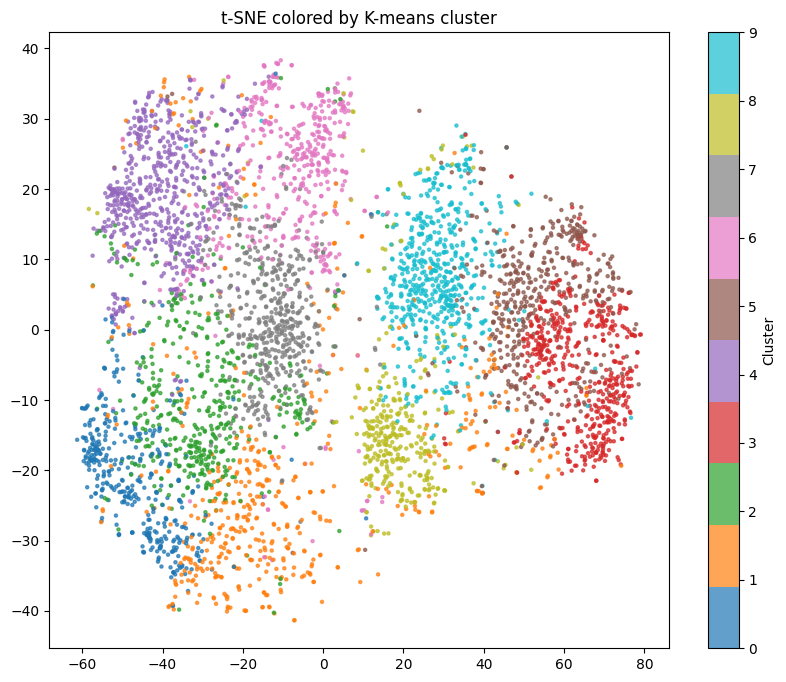

In [12]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# t-SNE on a subset (full 50k is too slow)
N = 5000
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(features[:N])

# Plot colored by cluster
plt.figure(figsize=(10, 8))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], 
                      c=cluster_labels[:N], cmap='tab10', s=5, alpha=0.7)
plt.colorbar(scatter, label='Cluster')
plt.title('t-SNE colored by K-means cluster')
plt.show()


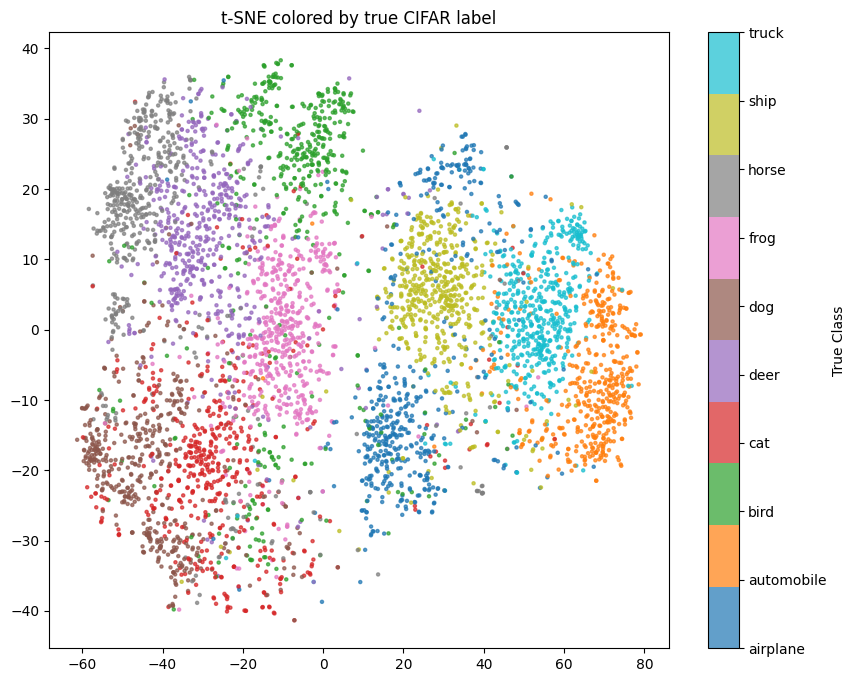

In [13]:
cifar_classes = ['airplane','automobile','bird','cat','deer',
                 'dog','frog','horse','ship','truck']

plt.figure(figsize=(10, 8))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                      c=labels_true[:N], cmap='tab10', s=5, alpha=0.7)
cbar = plt.colorbar(scatter, label='True Class')
cbar.set_ticks(range(10))
cbar.set_ticklabels(cifar_classes)
plt.title('t-SNE colored by true CIFAR label')
plt.show()


/home/as5606/miniconda3/envs/embeddings/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


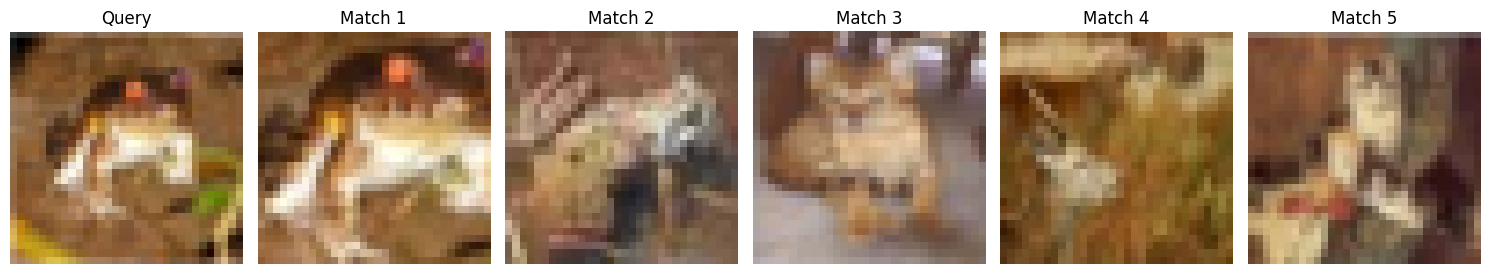

In [14]:
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from torchvision.datasets import CIFAR10

# Load dataset without transform for display
dataset_raw = CIFAR10(root='./data', train=True, download=False)

def retrieve(query_idx, top_k=5):
    query_vec = features[query_idx].reshape(1, -1)
    sims = cosine_similarity(query_vec, features)[0]
    top_indices = np.argsort(sims)[::-1][1:top_k+1]  # exclude query itself
    
    # Plot
    fig, axes = plt.subplots(1, top_k+1, figsize=(15, 3))
    axes[0].imshow(dataset_raw[query_idx][0])
    axes[0].set_title('Query')
    axes[0].axis('off')
    
    for i, idx in enumerate(top_indices):
        axes[i+1].imshow(dataset_raw[idx][0])
        axes[i+1].set_title(f'Match {i+1}')
        axes[i+1].axis('off')
    
    plt.tight_layout()
    plt.show()

# Try it on image 0
retrieve(0, top_k=5)
